# 00. The Hardest Easy Problem

**The question.** Deduplicating person records looks easy — humans do it at a glance, and a
dozen lines of string matching gets you something that *looks* right. So why do census
bureaus, health services, and voter-roll custodians run entire departments around it, and why
does every national-scale system end up a carefully-guarded hybrid of rules, probabilities,
and clerical review? This notebook shows the problem before the lab argues about solutions:
real record groups where one person's strings barely overlap, and different people's records
barely differ — then runs a complete, honest, five-minute dedup end-to-end so you can see
both what cheap methods buy and exactly where they stop.

**What this notebook settles.** Nothing statistical — deliberately. It is the hook and the
calibration chapter: (1) it demonstrates, on `historical_50k`, why person dedup at scale is
hard; (2) it ships a measured end-to-end quickstart (blocking → scoring → clustering →
entity-level metrics with a real bootstrap CI), registered as `quickstart_dedup`; (3) it
measures THIS machine's throughput coefficients and registers them as `smoke_check` — the
only source any wall-clock claim in this repo is allowed to cite; and (4) it teaches you how
to read the rest of the series (tiers, placards, conjecture cards, artifact-stamped figures).

In [1]:
import time

import jellyfish
import numpy as np
import pandas as pd
from IPython.display import display

from er_lab.blocking import matchkeys, sparse
from er_lab.cluster.schemes import transitive_closure
from er_lab.config import config_hash, load_config_from_env, set_all_seeds
from er_lab.data.loaders import load_historical_50k
from er_lab.eval.bootstrap import MULTIPLIER_METRICS, bootstrap_ci
from er_lab.eval.metrics import blocking_metrics
from er_lab.infra.artifacts import ArtifactRegistry
from er_lab.infra.device import describe_platform, resolve_device, resolve_precision
from er_lab.models.encoders import build_encoder
from er_lab.reporting import cards, figures
from er_lab.serialize import serialize_frame

cfg = load_config_from_env()
registry = ArtifactRegistry.from_env()
figures.setup_style()
set_all_seeds(cfg.run.seed)
rng = np.random.default_rng(cfg.run.seed)

In [2]:
# Tier banner: every notebook states what it ran as, on what, under which config.
print(f"tier        : {cfg.run.tier}")
print(f"config hash : {config_hash(cfg)}")
for key, val in describe_platform().items():
    print(f"{key:>13s} : {val}")

tier        : smoke
config hash : 129c9d9243ca
           os : Linux-6.18.44-fc-v22-x86_64-with-glibc2.39
       python : 3.11.15
        torch : 2.13.0+cu130
cuda_available : False
mps_available : False
    cpu_count : 4
       ram_gb : 15.7


Tier-conditional sizes live here, at the top, so a reader can see exactly what scales and
nothing else changes between tiers — one code path, different budgets (PLAN §2).

In [3]:
TIER = str(cfg.run.tier)
SIZES = {"smoke": 8_000, "mid": None, "target": None}  # records; None = the full corpus
ENC_TEXTS = {"smoke": 256, "mid": 2_048, "target": 8_192}  # encoder micro-benchmark batch
N_BOOT = {"smoke": 500, "mid": 1_000, "target": 2_000}  # bootstrap replicates
BM25_K = 5  # neighbors per record in the BM25 micro-benchmark
JW_THRESHOLD = 0.90  # quickstart link threshold — fixed a priori, never tuned (see §2)

n_target = SIZES.get(TIER, SIZES["smoke"])
n_enc = ENC_TEXTS.get(TIER, ENC_TEXTS["smoke"])
n_boot = N_BOOT.get(TIER, N_BOOT["smoke"])

## 1. The hook: what do these records actually look like?

`historical_50k` is a corpus of ~50k records describing ~5k real historical figures
(Wikidata-derived, with injected errors — the splink teaching dataset). Each *cluster* of
records describes one person; the `entity_id` column is the ground-truth key. It is tiny by
this lab's standards, and it already contains every pathology that makes person ER hard.
We load it verbatim — no cleaning, ever, at load time: the noise is the object of study.

In [4]:
full, schema = load_historical_50k(cfg.paths.data_root)
print(f"{len(full):,} records, {full['entity_id'].nunique():,} true entities")
print(f"text roles (declared schema order): {schema.text_roles()}")
display(full.head(4)[["record_id", "full_name", "given_name", "family_name", "dob", "city"]])

[er_lab.data] splink_datasets: splink_datasets (moj-analytical-services): openly downloadable; fake_1000 is synthetic, historical_50k is Wikidata-derived with injected errors; fetched at run time for quickstart and CI fixtures (DATA_GOVERNANCE.md).
50,578 records, 5,156 true entities
text roles (declared schema order): ['full_name', 'given_name', 'family_name', 'dob', 'city', 'zip', 'sex']


,record_id,full_name,given_name,family_name,dob,city
0,Q2296770-1,"thomas clifford, 1st baron clifford of chudleigh",thomas,chudleigh,1630-08-01,devon
1,Q2296770-2,thomas of chudleigh,thomas,chudleigh,1630-08-01,devon
2,Q2296770-3,tom 1st baron clifford of chudleigh,tom,chudleigh,1630-08-01,devon
3,Q2296770-4,thomas 1st chudleigh,thomas,chudleigh,1630-08-01,devon


### Same person, wildly different strings

First pathology: one entity whose records barely share a token. We *compute* the worst
offenders rather than cherry-picking by hand: for every entity we take its distinct
`full_name` variants and score the largest token-set (Jaccard) distance between any two of
them — 1.0 means the entity contains two name variants with **no tokens in common at all**.
The selection below is a deterministic query against this run's data.

In [5]:
HOOK_COLS = ["full_name", "given_name", "family_name", "dob", "city", "zip", "entity_id"]


def name_spread(names: list[str]) -> float:
    """Largest pairwise token-set Jaccard distance among an entity's name variants."""
    toks = [frozenset(n.split()) for n in names]
    worst = 0.0
    for i in range(len(toks)):
        for j in range(i + 1, len(toks)):
            union = toks[i] | toks[j]
            worst = max(worst, 1.0 - len(toks[i] & toks[j]) / len(union))
    return worst


variants = full.dropna(subset=["full_name"]).groupby("entity_id")["full_name"].unique()
spread_tbl = pd.DataFrame(
    {
        "spread": variants.map(lambda v: name_spread(list(v))),
        "n_name_variants": variants.map(len),
        "n_records": full.groupby("entity_id").size(),
    }
).query("n_records >= 8")
spread_tbl = spread_tbl.reset_index().sort_values(
    ["spread", "n_name_variants", "n_records", "entity_id"],
    ascending=[False, False, False, True],
)
display(spread_tbl.head(3))

,entity_id,spread,n_name_variants,n_records
2086,Q6138693,1.0,18,20
1469,Q4720059,1.0,18,19
952,Q2385895,1.0,17,21


In [6]:
for eid in spread_tbl["entity_id"].head(2):
    print(f"--- all records of entity {eid} (one real person) ---")
    display(full.loc[full["entity_id"] == eid, HOOK_COLS].head(10))

--- all records of entity Q6138693 (one real person) ---


,full_name,given_name,family_name,dob,city,zip,entity_id
22147,"james mackay, 1st earl of inchcape",james,inchcape,1852-09-11,arbroath,dd11 4bb,Q6138693
22148,"james mackay, earl of inchcape",james,inchcape,1852-09-11,arbroath,dd11 4bb,Q6138693
22149,james earl inchcape,james,inchcape,1852-09-11,arbroath,dd11 4bb,Q6138693
22150,james of inchcape,james,inchcape,1822-09-11,arbroath,dd11 4bb,Q6138693
22151,james 1st of inchcape,james,inchcape,1852-09-11,angus,dd11 4bb,Q6138693
22152,"james mackay, inchcape",james,inchcape,1852-09-11,arbroath,dd11 4bb,Q6138693
22153,"james mackay, earl inchcape",james,inchcape,1852-09-11,<NA>,<NA>,Q6138693
22154,"jamey mackay, 1st earl mckay inchcape",jamey,inchcape,1852-09-11,arbroath,<NA>,Q6138693
22155,james 1st of inchcape,james,inchcape,1852-09-11,arbroath,dd11 4bb,Q6138693
22156,james mackay,james,mackay,1852-09-11,arbroath,dd11 4qh,Q6138693


--- all records of entity Q4720059 (one real person) ---


,full_name,given_name,family_name,dob,city,zip,entity_id
2506,"alexander seton, 3rd earl of dunfermline",alexander,dunfermline,1642-06-12,canterbury,ct6 6ty,Q4720059
2507,"alexander seton, dunfermline",alexander,dunfermline,1642-06-12,canterbury,ct6 6ty,Q4720059
2508,"alexander seton, 3rd earl of dunfermline",alexander,dunfermline,1642-06-12,<NA>,ct6 6nf,Q4720059
2509,alexander earl dunfermline,alexander,dunfermline,1642-05-12,canterbury,ct6 6ty,Q4720059
2510,alexander 3rd dunfermline,alexander,dunfermline,1642-06-12,canterbury,ct6 6ty,Q4720059
2511,alexander 3rd earl of dunfermline,alexander,dunfermline,1642-06-12,canterbury,ct6 6ty,Q4720059
2512,"zander seton, 3rd of seaton dunfermline",zander,dunfermline,1642-06-13,canterbury,ct6 6ty,Q4720059
2513,"alexander seton, 3rd dunfermline",alexander,dunfermline,1642-06-15,canterbury,<NA>,Q4720059
2514,sandy earl dunfermline,sandy,dunfermline,<NA>,canterbury,ct6 6ty,Q4720059
2515,"alexander seton, of dunfermline",alexander,dunfermline,1612-06-12,canterbury,<NA>,Q4720059


Look at what a matcher is being asked to survive: nickname substitution, initials, surname
replacement, titles absorbed into the name, digits corrupted inside the date of birth,
fields simply gone. Every one of these is a *documented* real-world error channel (the lab
measures their real prevalence in notebook 04); here they pile up inside a single identity.

### Different people, near-identical strings

Second pathology — the mirror image. We compute the multi-token name (excluding bare
title fragments like "sir … baronet") that is shared by the *most distinct true entities*,
and show one record from each of the people who carry it.

In [7]:
named = full.dropna(subset=["full_name", "given_name", "family_name"])
plain = named[
    ~named["full_name"].str.contains(r"\b(?:sir|baronet|bt\.?|1st|2nd|3rd)\b", regex=True)
]
multi = plain[plain["full_name"].str.split().str.len() >= 2]
share = (
    multi.groupby("full_name")["entity_id"]
    .nunique()
    .rename("n_entities")
    .reset_index()
    .sort_values(["n_entities", "full_name"], ascending=[False, True])
)
top_name = share.iloc[0]["full_name"]
print(f"most entity-shared plain name: '{top_name}' " f"({share.iloc[0]['n_entities']} people)")
display(
    full.loc[full["full_name"] == top_name, HOOK_COLS].drop_duplicates("entity_id").head(6)
)

most entity-shared plain name: 'john williams' (5 people)


,full_name,given_name,family_name,dob,city,zip,entity_id
9158,john williams,john,williams,1710-01-01,southwark,se15 3uq,Q19745229
13801,john williams,john,williams,1857-05-24,abergavenny,np7 6lx,Q2492966
20739,john williams,john,williams,1582-03-25,conwy,ll32 8hj,Q3182765
28971,john williams,john,williams,<NA>,lambeth,da9 9uz,Q6225803
46998,john williams,john,williams,1857-04-25,birmingham,<NA>,Q47624217


Same name, different people — sometimes in nearby places, sometimes with equally-vague
birth dates. Nothing in these strings says "distinct"; only the surrounding evidence does.

### Hub values: the strings that glue everything together

Third pathology: a handful of name strings are shared across *dozens* of entities. These
are the "hub values" of the chain-merge literature — any method that trusts exact string
equality inherits every hub as a ready-made false-merge highway.

In [8]:
hubs = (
    full.dropna(subset=["full_name"])
    .groupby("full_name")["entity_id"]
    .nunique()
    .rename("n_distinct_entities")
    .sort_values(ascending=False)
    .head(10)
)
display(hubs.to_frame())

,n_distinct_entities
full_name,
william,71
john,68
thomas,44
sir baronet,44
willie,37
tom,36
harry,35
charles,34
george,33


### Why this becomes brutal at 10⁹

At 50k records these pathologies are curiosities; at national scale they are the whole
problem. Three compounding mechanisms (lit review §1, §3, §5): **pair mass** — candidate
pairs grow with n², so at 10⁹ records a blocker must discard all but ~one in a billion
pairs while somehow keeping the true ones, and every rare error mode gets ~10⁹ chances per
error rate to occur; **chain merges** — pairwise decisions are stitched into entities by
transitive closure, so a single false link between two hub-heavy clusters fuses two real
people irreversibly, and replicated production experience shows mega-components glued
together exactly this way (shared households, placeholder values, frequent names);
**name frequency** — person names are heavy-tailed, so "identical name string" stops being
evidence precisely where the collisions concentrate (we just watched several distinct
people share a name inside a corpus of *famous* historical figures; a national corpus
holds tens of thousands of collisions per common name). Cheap signals saturate, and the
question stops being "can you match strings" and becomes "can you budget errors" — which
is why this lab is built around measurement and statistics rather than around a clever
matcher.

## 2. The five-minute end-to-end

Can we dedup this corpus in one screenful of honest code — and what does "good" even mean?
We run the naive-but-complete recipe every practitioner writes first:

1. **Block** with deterministic matchkeys (OR-union of cheap compound keys), because all
   pairs is n² and already unaffordable at 50k.
2. **Score** each candidate pair with the mean Jaro-Winkler similarity over the
   `given_name` / `family_name` / `dob` fields. This is a deliberately cheap strawman —
   it is **NOT** the lab's Fellegi-Sunter baseline. The baseline that must actually be
   beaten is a *well-tuned* Splink FS model (TF-adjusted, comparison-binned), built and
   measured in notebook 06 (BAS-01). Nothing in this notebook is evidence about FS.
3. **Cluster** by transitive closure at a threshold fixed a priori at 0.90 — we never
   tune a threshold to flatter a method (MET-02, notebook 02, demonstrates how per-method
   best-F1 comparisons lie).
4. **Evaluate at the entity level** with a real bootstrap CI, resampled by entity —
   records of one person share their fate, so record-level resampling would fake
   independence (MET-03 demonstrates the coverage failure).

The subsample is *entity-complete*: we draw whole entities until the record budget is
reached, never splitting a person across the cut — a split entity would corrupt recall
accounting. At smoke tier that is ~8k records; at mid/target the full corpus.

In [9]:
def entity_complete_subsample(
    frame: pd.DataFrame, n_records: int | None, rng: np.random.Generator
) -> pd.DataFrame:
    """Random whole entities until ~n_records — an entity is never split across the cut."""
    if n_records is None or n_records >= len(frame):
        return frame.reset_index(drop=True)
    ents = frame["entity_id"].unique()
    sizes = frame["entity_id"].value_counts()
    picked: list[str] = []
    total = 0
    for i in rng.permutation(len(ents)):
        picked.append(ents[i])
        total += int(sizes[ents[i]])
        if total >= n_records:
            break
    return frame[frame["entity_id"].isin(set(picked))].reset_index(drop=True)


sub = entity_complete_subsample(full, n_target, rng)
truth = sub.set_index("record_id")["entity_id"]
print(f"quickstart corpus: {len(sub):,} records, {truth.nunique():,} entities (tier={TIER})")

quickstart corpus: 8,020 records, 847 entities (tier=smoke)


Before running anything we pre-register what we expect — this is the series' core habit.
The card below is immutable: it is hashed and stored the first time this cell ever runs,
and any later edit to its text is a protocol violation the registry itself will refuse.

In [10]:
CARD_ID = "NB00-quickstart"
PRED_PREC_MIN, PRED_REC_MAX, PRED_PC_MAX = 0.95, 0.70, 0.70
_card_md = cards.conjecture_card(
    card_id=CARD_ID,
    conjecture=(
        "On historical_50k, the naive quickstart (matchkey blocking, mean Jaro-Winkler "
        "field similarity, transitive closure) solves only the easy half of person dedup: "
        "entity-level precision stays high while entity-level recall is left far behind, "
        "capped by the pairs blocking never proposed."
    ),
    pressure=(
        "No learned pressure — the dial is the pipeline recipe itself: matchkeys OR-union "
        "blocking, mean Jaro-Winkler over given_name/family_name/dob, transitive closure "
        f"at threshold {JW_THRESHOLD:.2f} fixed a priori (never tuned per MET-02)."
    ),
    property=(
        "Not an embedding property in this notebook; the measured mediator is blocking "
        "pair-completeness, which upper-bounds all downstream recall — a pair never "
        "proposed can never be linked."
    ),
    metric=(
        "Entity-level B-cubed precision and recall on the tier-sized historical_50k "
        "subsample, with entity-unit BCa 95% bootstrap CIs."
    ),
    prediction=(
        f"B-cubed precision >= {PRED_PREC_MIN:.2f} and B-cubed recall <= {PRED_REC_MAX:.2f}; "
        f"blocking pair-completeness < {PRED_PC_MAX:.2f}, naming blocking as the binding "
        "constraint; precision's CI lower bound stays above recall's CI upper bound."
    ),
    registry=registry,
)

### Conjecture card `NB00-quickstart`

| | |
|---|---|
| **Conjecture** | On historical_50k, the naive quickstart (matchkey blocking, mean Jaro-Winkler field similarity, transitive closure) solves only the easy half of person dedup: entity-level precision stays high while entity-level recall is left far behind, capped by the pairs blocking never proposed. |
| **Pressure (dial)** | No learned pressure — the dial is the pipeline recipe itself: matchkeys OR-union blocking, mean Jaro-Winkler over given_name/family_name/dob, transitive closure at threshold 0.90 fixed a priori (never tuned per MET-02). |
| **Embedding property** | Not an embedding property in this notebook; the measured mediator is blocking pair-completeness, which upper-bounds all downstream recall — a pair never proposed can never be linked. |
| **System metric** | Entity-level B-cubed precision and recall on the tier-sized historical_50k subsample, with entity-unit BCa 95% bootstrap CIs. |
| **Pre-registered prediction** | B-cubed precision >= 0.95 and B-cubed recall <= 0.70; blocking pair-completeness < 0.70, naming blocking as the binding constraint; precision's CI lower bound stays above recall's CI upper bound. |

*Immutable — sha256 `6616c59104cd`; registered before the affected runs, never edited (PLAN §5).*


**Step 1 — blocking.** `matchkeys.candidates` derives cheap compound keys per record
(soundex of the surname + birth year; postcode + first initial) and pairs records sharing
a key, OR-union over passes — the design every national-scale system uses (~10 passes at
the US Census, 29 matchkeys at ONS). It exists because comparing everything to everything
is quadratic: even our subsample would otherwise mean tens of millions of comparisons.

In [11]:
t_pipeline = time.perf_counter()
t0 = time.perf_counter()
cand = matchkeys.candidates(sub)
t_block = time.perf_counter() - t0
print(f"{len(cand):,} candidate pairs from {len(sub):,} records in {t_block:.2f}s")
display(pd.DataFrame(cand.attrs["stats"]["passes"]))

24,129 candidate pairs from 8,020 records in 0.17s


,keys,n_blocks,max_block,pairs_generated,pairs_new
0,"[soundex(family_name), year(dob)]",903,25,17600,17600
1,"[zip, initial(given_name)]",1018,18,13017,6529


How much did blocking throw away, and how much truth did it keep? Reduction ratio is the
discarded fraction of all possible pairs; pair completeness is the fraction of true
same-entity pairs that survived. The second number is the ceiling on everything downstream.

In [12]:
bstats = blocking_metrics(cand, truth, n_records=len(sub))
display(pd.DataFrame([bstats]))

,reduction_ratio,pair_completeness,pairs_kept,n_true_pairs,n_true_pairs_found,n_comparisons_total
0,0.99925,0.485637,24129,47099,22873,32156190


**Step 2 — scoring.** Mean Jaro-Winkler similarity over `given_name`, `family_name`, and
`dob`, averaged over the fields present in both records (a pair with no comparable field
scores 0). Jaro-Winkler is the classical typo-tolerant name comparator; averaging it
uniformly over three fields is exactly the kind of ad-hoc weighting Fellegi-Sunter
replaces with estimated evidence weights — which is why this scorer is a strawman and
notebook 06's tuned Splink model is the real baseline.

In [13]:
SCORE_FIELDS = ["given_name", "family_name", "dob"]


def jw_column(x: pd.Series, y: pd.Series) -> np.ndarray:
    """Jaro-Winkler per aligned row; NaN where either side is missing."""
    out = np.full(len(x), np.nan)
    for i, (u, v) in enumerate(zip(x, y)):
        if not (pd.isna(u) or pd.isna(v)):
            out[i] = jellyfish.jaro_winkler_similarity(str(u), str(v))
    return out


t0 = time.perf_counter()
lut = sub.set_index("record_id")[SCORE_FIELDS]
left = lut.loc[cand["a"]].reset_index(drop=True)
right = lut.loc[cand["b"]].reset_index(drop=True)
sim_mat = np.column_stack([jw_column(left[f], right[f]) for f in SCORE_FIELDS])
n_valid = (~np.isnan(sim_mat)).sum(axis=1)
sims = np.where(n_valid > 0, np.nansum(sim_mat, axis=1) / np.maximum(n_valid, 1), 0.0)
scored = pd.DataFrame({"a": cand["a"], "b": cand["b"], "prob": sims})
t_score = time.perf_counter() - t0
print(f"scored {len(scored):,} pairs in {t_score:.2f}s")
display(scored["prob"].describe().to_frame().T)

scored 24,129 pairs in 0.10s


,count,mean,std,min,25%,50%,75%,max
prob,24129.0,0.931617,0.097385,0.227778,0.913651,0.969841,1.0,1.0


**Step 3 — clustering.** Transitive closure: link every pair at or above the threshold and
take connected components. This is what naive pipelines do, and it is the chain-merge
catastrophe's enabling mechanism — one bad edge fuses two people irreversibly. Notebook 07
stages that catastrophe deliberately; here we just note the largest predicted cluster
against the largest true entity.

In [14]:
t0 = time.perf_counter()
pred = transitive_closure(scored, threshold=JW_THRESHOLD, records=pd.Index(truth.index))
t_cluster = time.perf_counter() - t0
print(f"{pred.nunique():,} predicted clusters in {t_cluster:.2f}s")
print(f"largest predicted cluster: {int(pred.value_counts().iloc[0])} records")
print(f"largest true entity      : {int(truth.value_counts().iloc[0])} records")

3,116 predicted clusters in 0.03s
largest predicted cluster: 24 records
largest true entity      : 21 records


**Step 4 — entity-level metrics, with a real CI.** B-cubed scores each *record* on how
pure and complete its predicted cluster is, so one mega-merge costs what it should;
pairwise P/R is reported alongside because most of the literature speaks it. The CI
resamples *entities* (BCa, bias-corrected): records of one person are not independent
evidence, and pretending otherwise is how evaluations under-report their own noise.

In [15]:
t0 = time.perf_counter()
ci_rows = []
for metric_name in MULTIPLIER_METRICS:
    res = bootstrap_ci(
        pred, truth, metric_name, unit="entity", n_boot=n_boot, seed=cfg.run.seed
    )
    ci_rows.append(
        {
            "metric": metric_name,
            "value": res["point"],
            "ci_low": res["ci_low"],
            "ci_high": res["ci_high"],
        }
    )
t_eval = time.perf_counter() - t0
runtime_s = time.perf_counter() - t_pipeline
print(f"bootstrap ({n_boot} replicates x {len(MULTIPLIER_METRICS)} metrics): {t_eval:.2f}s")
print(f"end-to-end pipeline wall-clock: {runtime_s:.2f}s")

bootstrap (500 replicates x 6 metrics): 1.25s
end-to-end pipeline wall-clock: 1.64s


Everything the quickstart measured becomes one registered artifact — `quickstart_dedup`,
one row per metric — and the figure below renders *from the registry*, not from variables
in memory. That indirection is the lab's honesty rail for figures (see §4).

In [16]:
qd = pd.DataFrame(
    ci_rows
    + [
        {"metric": "pair_completeness", "value": bstats["pair_completeness"]},
        {"metric": "reduction_ratio", "value": bstats["reduction_ratio"]},
        {"metric": "n_records", "value": float(len(sub))},
        {"metric": "n_entities", "value": float(truth.nunique())},
        {"metric": "n_candidate_pairs", "value": float(len(cand))},
        {"metric": "n_pred_clusters", "value": float(pred.nunique())},
        {"metric": "runtime_s", "value": runtime_s},
    ]
)
registry.register(
    "quickstart_dedup",
    qd,
    cfg=cfg,
    tier=cfg.run.tier,
    meta={
        "corpus": "historical_50k",
        "scorer": "mean Jaro-Winkler over given_name/family_name/dob — NOT the FS baseline "
        "(that is notebook 06 / BAS-01)",
        "blocking": "matchkeys.default_passes",
        "clustering": f"transitive_closure @ {JW_THRESHOLD:.2f} (fixed a priori)",
        "bootstrap": {"unit": "entity", "method": "bca", "n_boot": n_boot},
    },
)
display(qd)

,metric,value,ci_low,ci_high
0,bcubed_precision,0.995840,0.990950,0.998020
1,bcubed_recall,0.528094,0.514683,0.543572
2,bcubed_f1,0.690183,0.678630,0.703587
3,pairwise_precision,0.984905,0.910766,0.997665
4,pairwise_recall,0.468227,0.452067,0.487008
5,pairwise_f1,0.634710,0.616792,0.653472
6,pair_completeness,0.485637,NaN,NaN
7,reduction_ratio,0.999250,NaN,NaN
8,n_records,8020.000000,NaN,NaN
9,n_entities,847.000000,NaN,NaN


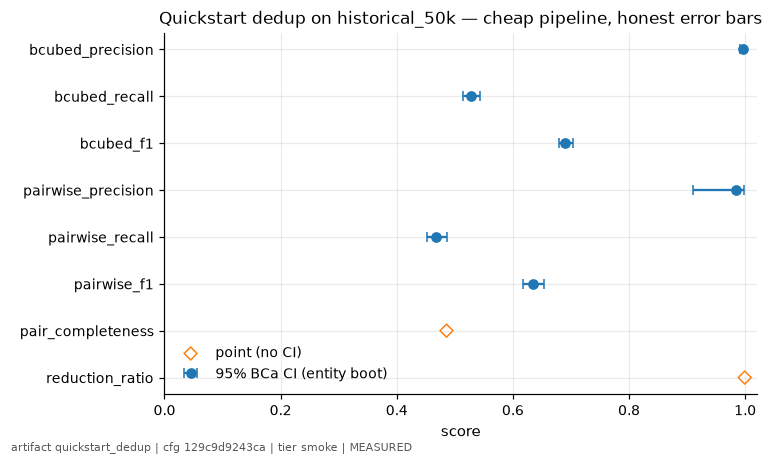

In [17]:
POINT_ONLY = ["pair_completeness", "reduction_ratio"]


def draw_quickstart(ax, frame: pd.DataFrame, meta: dict) -> None:
    banded = frame[frame["ci_low"].notna()].reset_index(drop=True)
    points = frame[frame["metric"].isin(POINT_ONLY)].reset_index(drop=True)
    y_b = np.arange(len(banded))
    y_p = np.arange(len(banded), len(banded) + len(points))
    xerr = np.vstack(
        [
            np.clip(banded["value"] - banded["ci_low"], 0, None),
            np.clip(banded["ci_high"] - banded["value"], 0, None),
        ]
    )
    ax.errorbar(
        banded["value"], y_b, xerr=xerr, fmt="o", capsize=3, label="95% BCa CI (entity boot)"
    )
    ax.scatter(
        points["value"], y_p, marker="D", facecolors="none", color="C1", label="point (no CI)"
    )
    ax.set_yticks(np.concatenate([y_b, y_p]))
    ax.set_yticklabels(list(banded["metric"]) + list(points["metric"]))
    ax.set_xlim(0, 1.02)
    ax.set_xlabel("score")
    ax.invert_yaxis()
    ax.legend(loc="lower left")


_fig = figures.plot_artifact(
    registry,
    tier=cfg.run.tier,
    artifact="quickstart_dedup",
    draw=draw_quickstart,
    title="Quickstart dedup on historical_50k — cheap pipeline, honest error bars",
    figsize=(7.0, 4.2),
)

The verdict below is computed from the registered numbers, never hand-written — the three
allowed outcomes are CONFIRMED / REFUTED / UNEXPLAINED, and UNEXPLAINED is reserved for
"the headline held but not through the pre-named mechanism".

In [18]:
qd_ix = qd.set_index("metric")
prec, rec = qd_ix.loc["bcubed_precision"], qd_ix.loc["bcubed_recall"]
pc = float(qd_ix.loc["pair_completeness", "value"])
prec_ok = prec["value"] >= PRED_PREC_MIN
rec_ok = rec["value"] <= PRED_REC_MAX
order_ok = prec["ci_low"] > rec["ci_high"]
pc_ok = pc < PRED_PC_MAX
if prec_ok and rec_ok and order_ok and pc_ok:
    outcome = "CONFIRMED"
elif prec_ok and rec_ok and order_ok:
    outcome = "UNEXPLAINED"
else:
    outcome = "REFUTED"
_verdict_md = cards.verdict_box(
    CARD_ID,
    outcome=outcome,
    evidence=(
        f"B-cubed precision {prec['value']:.3f} [{prec['ci_low']:.3f}, {prec['ci_high']:.3f}] "
        f"vs recall {rec['value']:.3f} [{rec['ci_low']:.3f}, {rec['ci_high']:.3f}] "
        f"(entity-unit BCa, n_boot={n_boot}); blocking pair-completeness {pc:.3f} on "
        f"{len(sub):,} records / {truth.nunique():,} entities at threshold "
        f"{JW_THRESHOLD:.2f}. Artifact: quickstart_dedup (tier {TIER})."
    ),
    registry=registry,
)

> ### VERDICT: CONFIRMED — card `NB00-quickstart`
>
> **Conjecture** On historical_50k, the naive quickstart (matchkey blocking, mean Jaro-Winkler field similarity, transitive closure) solves only the easy half of person dedup: entity-level precision stays high while entity-level recall is left far behind, capped by the pairs blocking never proposed.
>
> **Prediction** B-cubed precision >= 0.95 and B-cubed recall <= 0.70; blocking pair-completeness < 0.70, naming blocking as the binding constraint; precision's CI lower bound stays above recall's CI upper bound.
>
> **Evidence** B-cubed precision 0.996 [0.991, 0.998] vs recall 0.528 [0.515, 0.544] (entity-unit BCa, n_boot=500); blocking pair-completeness 0.486 on 8,020 records / 847 entities at threshold 0.90. Artifact: quickstart_dedup (tier smoke).


Read the figure, not the vibes. The cheap pipeline is genuinely excellent at *not* merging
different people — and it silently abandons a large share of each person's records,
with the blocking stage's pair-completeness as the visible ceiling. "Easy" was precision.
Recall — under noise, at scale, without a labeled answer key — is the hard part, and it is
where the rest of this series lives.

## 3. `smoke_check`: measuring THIS machine

The lab's honesty rails forbid quoted wall-clock numbers: any runtime claim in the README
or a later notebook must re-render from measured coefficients, and this section is where
those coefficients come from. We time four primitive operations on this machine, at this
tier, on real data from this run — and we project *nothing*. A single-shot timing on a
shared container is hostage to whatever else the machine was doing in that instant, so
each coefficient is the **median of 3 repeats** of the same small benchmark body, and the
repeat spread (min/max rate) is stored next to it — a citation of a coefficient carries
the measurement's own uncertainty. The registered `smoke_check` artifact is the citation
target; PLAN §8's planning estimates are hypotheses these measurements exist to replace.

In [19]:
N_REPEATS = 3  # each coefficient = median over N_REPEATS repeats of the same small body


def repeat_timed(fn) -> tuple[object, dict[str, float]]:
    """Run fn N_REPEATS times; return (last result, {'median','min','max'} seconds)."""
    times: list[float] = []
    result = None
    for _ in range(N_REPEATS):
        t0 = time.perf_counter()
        result = fn()
        times.append(time.perf_counter() - t0)
    return result, {"median": float(np.median(times)),
                    "min": float(min(times)), "max": float(max(times))}


def rate_spread(n: int, t: dict[str, float]) -> dict[str, float]:
    """Throughput from repeat timings: median rate plus its min/max spread."""
    return {"median": n / t["median"], "min": n / t["max"], "max": n / t["min"]}


texts, t_serialize = repeat_timed(lambda: serialize_frame(sub, text_roles=schema.text_roles()))
serialize_rate = rate_spread(len(sub), t_serialize)
print(f"serialize_frame: {len(sub):,} rows in {t_serialize['median']:.2f}s "
      f"(median of {N_REPEATS}; {t_serialize['min']:.2f}-{t_serialize['max']:.2f}s)")
print(f"example serialization:\n  {texts.iloc[0]}")

serialize_frame: 8,020 rows in 0.07s (median of 3; 0.06-0.07s)
example serialization:
  [COL] full_name [VAL] george thorp [COL] given_name [VAL] george [COL] family_name [VAL] thorp [COL] dob [VAL] 1777-09-09 [COL] city [VAL] chillingham [COL] zip [VAL] ne66 5nj [COL] sex [VAL] male


The encoder coefficient uses the lab's from-scratch byte-level transformer with UNTRAINED
weights — this measures compute cost per record, and says nothing about quality (training
starts in notebook 08). A tiny warm-up batch runs first so thread-pool spin-up is not
billed to the coefficient. Device and precision come from config resolution, so the same
cell measures CPU here and MPS/CUDA on the mac/node.

In [20]:
device = resolve_device(cfg)
dtype = resolve_precision(cfg, device)
encoder = build_encoder(cfg)
enc_params = int(sum(p.numel() for p in encoder.parameters()))
enc_texts = texts.iloc[:n_enc].tolist()
encoder.encode(enc_texts[:8], batch_size=8, device=device, dtype=dtype)  # warm-up
emb, t_encode = repeat_timed(
    lambda: encoder.encode(enc_texts, batch_size=int(cfg.train.batch_size),
                           device=device, dtype=dtype)
)
encode_rate = rate_spread(len(enc_texts), t_encode)
print(
    f"CharByteEncoder (untrained, {enc_params:,} params, dim {emb.shape[1]}, "
    f"device {device.type}): {len(enc_texts)} texts in {t_encode['median']:.2f}s "
    f"(median of {N_REPEATS}; {t_encode['min']:.2f}-{t_encode['max']:.2f}s)"
)

CharByteEncoder (untrained, 2,289,408 params, dim 256, device cpu): 256 texts in 1.50s (median of 3; 1.49-1.61s)


In [21]:
bm25_pairs, t_bm25 = repeat_timed(lambda: sparse.candidates(sub, texts, k=BM25_K))
bm25_rate = rate_spread(len(sub), t_bm25)
print(f"BM25 build+query (k={BM25_K}): {len(sub):,} records in {t_bm25['median']:.2f}s "
      f"(median of {N_REPEATS}; {t_bm25['min']:.2f}-{t_bm25['max']:.2f}s)")

mk_pairs, t_matchkeys = repeat_timed(lambda: matchkeys.candidates(sub))
matchkeys_rate = rate_spread(len(mk_pairs), t_matchkeys)
print(f"matchkeys: {len(mk_pairs):,} pairs in {t_matchkeys['median']:.2f}s "
      f"(median of {N_REPEATS}; {t_matchkeys['min']:.2f}-{t_matchkeys['max']:.2f}s)")

BM25 build+query (k=5): 8,020 records in 3.74s (median of 3; 3.66-4.29s)


matchkeys: 24,129 pairs in 0.15s (median of 3; 0.15-0.17s)


In [22]:
smoke_check = {
    "platform": describe_platform(),
    "tier": TIER,
    "device": device.type,
    "coefficient_repeats": N_REPEATS,  # each *_per_s is the median; *_spread is [min, max]
    "measured": {
        "serialize_rows_per_s": float(serialize_rate["median"]),
        "serialize_rows_per_s_spread": [float(serialize_rate["min"]),
                                        float(serialize_rate["max"])],
        "serialize_n_rows": len(sub),
        "charbyte_encode_texts_per_s": float(encode_rate["median"]),
        "charbyte_encode_texts_per_s_spread": [float(encode_rate["min"]),
                                               float(encode_rate["max"])],
        "charbyte_encode_n_texts": len(enc_texts),
        "charbyte_encode_batch_size": int(cfg.train.batch_size),
        "charbyte_params": enc_params,
        "charbyte_dim": int(emb.shape[1]),
        "charbyte_untrained": True,
        "bm25_build_query_records_per_s": float(bm25_rate["median"]),
        "bm25_build_query_records_per_s_spread": [float(bm25_rate["min"]),
                                                  float(bm25_rate["max"])],
        "bm25_n_records": len(sub),
        "bm25_k": int(BM25_K),
        "bm25_n_pairs": len(bm25_pairs),
        "matchkeys_pairs_per_s": float(matchkeys_rate["median"]),
        "matchkeys_pairs_per_s_spread": [float(matchkeys_rate["min"]),
                                         float(matchkeys_rate["max"])],
        "matchkeys_n_pairs": len(mk_pairs),
        "matchkeys_n_records": len(sub),
        "quickstart_runtime_s": float(runtime_s),
    },
}
registry.register(
    "smoke_check",
    smoke_check,
    cfg=cfg,
    tier=cfg.run.tier,
    meta={"note": "measured throughput coefficients (median of "
                  f"{N_REPEATS} repeats, min/max spread stored); "
                  "the only citable wall-clock source"},
)
coeff_table = pd.DataFrame(
    [
        ("serialize_frame", serialize_rate["median"], serialize_rate["min"],
         serialize_rate["max"], "rows/s", len(sub)),
        ("CharByteEncoder.encode (untrained)", encode_rate["median"], encode_rate["min"],
         encode_rate["max"], "texts/s", len(enc_texts)),
        (f"BM25 build+query (k={BM25_K})", bm25_rate["median"], bm25_rate["min"],
         bm25_rate["max"], "records/s", len(sub)),
        ("matchkeys blocking", matchkeys_rate["median"], matchkeys_rate["min"],
         matchkeys_rate["max"], "pairs/s", len(mk_pairs)),
        ("quickstart end-to-end", runtime_s, np.nan, np.nan, "s wall-clock (single run)",
         len(sub)),
    ],
    columns=["coefficient", "median", "min", "max", "unit", "n_measured"],
)
display(coeff_table)
print(
    f"Measured on this machine, this run (tier={TIER}, device={device.type}); each\n"
    f"coefficient is the median of {N_REPEATS} repeats with its min/max spread alongside —\n"
    "on a shared container a single-shot timing can swing several-fold with ambient load,\n"
    "so cite the median WITH its spread. These are coefficients, not projections: later\n"
    "notebooks and the README cite the registered smoke_check artifact instead of quoting\n"
    "wall-clock folklore. Nothing on this table says anything about 1e9 — the cost model\n"
    "that does (SCL-03, notebook 15) is built from measured coefficients like these and is\n"
    "labeled EXTRAPOLATED wherever it leaves measurement behind."
)

,coefficient,median,min,max,unit,n_measured
0,serialize_frame,120150.224935,106984.520434,132931.231278,rows/s,8020
1,CharByteEncoder.encode (untrained),170.312202,158.946044,171.367217,texts/s,256
2,BM25 build+query (k=5),2144.184392,1867.486962,2193.524944,records/s,8020
3,matchkeys blocking,157348.879343,138659.549533,157409.148618,pairs/s,24129
4,quickstart end-to-end,1.638401,NaN,NaN,s wall-clock (single run),8020


Measured on this machine, this run (tier=smoke, device=cpu); each
coefficient is the median of 3 repeats with its min/max spread alongside —
on a shared container a single-shot timing can swing several-fold with ambient load,
so cite the median WITH its spread. These are coefficients, not projections: later
notebooks and the README cite the registered smoke_check artifact instead of quoting
wall-clock folklore. Nothing on this table says anything about 1e9 — the cost model
that does (SCL-03, notebook 15) is built from measured coefficients like these and is
labeled EXTRAPOLATED wherever it leaves measurement behind.


## 4. How to read this series

**Tiers.** Every notebook runs at `smoke` (a 4-CPU container, minutes, subsampled data),
`mid` (the lab's M2 Max, ~1e6 records), or `target` (one 4xA100 node, ~1e7) — the tier
only ever arrives through config (`run.tier`), never through forked notebook logic, so the
cell you read is the cell that runs at every scale. Sizes and budgets sit in
tier-conditional constants at the top of each notebook (like `SIZES` above); `analytical`
marks work that is pure computation over registered measurements. Artifacts from
different tiers never mix: the registry refuses to serve a smoke artifact to a target run.

**RUN-IN-TARGET placards.** A cell whose real run only makes sense on the mac or the node
carries a `# [RUN-IN-TARGET mac]` (or `node`) comment and, at smoke, prints a placard
saying what it computes and where, instead of pretending. This notebook has none — the
quickstart's entire point is running end-to-end anywhere — but from notebook 06 onward you
will meet cells that print, e.g.:

```
[RUN-IN-TARGET mac] this cell fine-tunes the pretrained encoder at tier=mid;
at smoke it is skipped.
```

Same cell, same code path — only the tier changes.

**Conjecture cards.** Every claim-bearing computation is preceded by a pre-registered
conjecture (pressure → measurable property → system metric, with a directional
prediction), rendered and hash-frozen *before* the results exist, and closed by a verdict
box that must honestly read CONFIRMED, REFUTED, or UNEXPLAINED off the computed numbers.
Cards are immutable — re-rendering an edited card raises an error by design — so a verdict
can never quietly rewrite what was predicted. UNEXPLAINED is a first-class outcome: an
effect can be real while its claimed mechanism is not.

**Artifact-stamped figures.** No figure in this series renders from an in-memory frame.
Data is first registered (name, tier, config hash, git revision, timestamp), and figures
load it back through `er_lab.reporting.figures`, which stamps every plot with its artifact
name, config hash, tier, and a MEASURED / EXTRAPOLATED flag — extrapolated segments render
dashed, shaded, and watermarked. If a figure exists, its data provably came from a
registered run of a named notebook; if the upstream notebook has not run, you get a
"NOT YET RUN" placard instead of a picture.

## What we now know / What this changes downstream

**What we now know.** On real person records, the failure modes come in mirrored pairs:
one person's strings can share almost nothing while two people's records are
near-identical, and a few hub name-values are shared across dozens of true entities. A
complete cheap pipeline (matchkeys → mean Jaro-Winkler → transitive closure) runs on this
corpus in well under the five-minute budget and is precise but recall-starved, with
blocking pair-completeness the measured ceiling — exact numbers, with entity-bootstrap
CIs, in `quickstart_dedup` and stamped on the figure above. This machine's measured
throughput coefficients (serialization, untrained byte-encoder encode, BM25 build+query,
matchkey pair generation) are registered in `smoke_check` — each as the median of
repeated timings with its min/max spread stored alongside, so a citation carries the
measurement's own uncertainty.

**What this changes downstream.** `smoke_check` becomes the only legitimate source for
wall-clock and cost statements (the README quickstart claim re-renders from it; SCL-03's
1e9 cost model starts from coefficients measured like these). `quickstart_dedup` is the
strawman reference point later notebooks improve on — and the metrics discipline it
previews (entity-level scores, entity-unit bootstrap, fixed a-priori operating points) is
built properly in notebook 02 before any model is trained. The scorer used here is
explicitly not the baseline; notebook 06 (BAS-01) builds the Fellegi-Sunter model that
embeddings must actually beat.

**Artifacts registered by this notebook:** `smoke_check`, `quickstart_dedup`.